# 03 · Automated variance flagging

**Goal:** each month, tell budget owners which lines need attention and draft the explanation. That replaces an analyst scanning 27 lines × 3 comparisons by hand.

**The rules** (thresholds in `config/variance_rules.yaml`):

| Status | Meaning | Rule |
|---|---|---|
| 🔴 **Red: investigate** | off plan *and* not explainable by the trend | variance vs budget is **material** (≥ $ threshold **and** ≥ % threshold) **and** the actual is **outside the expected range** of last month's forecast |
| 🟠 **Amber: explain / monitor** | known gap, small surprise, or creeping drift | material but expected, **or** unexpected but below materiality, **or** off budget in the same direction for 3+ months |
| 🟢 **Green: on track** | nothing to say | none of the above |

Revenue and cost signs are handled so that *favourable* and *unfavourable* always mean what finance means.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from fpa import viz
from fpa.viz import ROLE, month_axis, plt, usd, usd_axis

viz.use_style()
pd.set_option("display.max_colwidth", 200)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MARTS = ROOT / "data" / "marts"
read = lambda name: pd.read_parquet(MARTS / f"{name}.parquet")
meta = json.loads((MARTS / "run_metadata.json").read_text())
AS_OF = meta["as_of"]
flags = read("variance_monthly")
print(yaml.safe_dump(yaml.safe_load((ROOT / "config" / "variance_rules.yaml").read_text()), sort_keys=False))

default:
  abs_usd: 50000
  pct: 0.1
by_fs_line:
  Subscription Revenue:
    abs_usd: 150000
    pct: 0.03
  Services Revenue:
    abs_usd: 75000
    pct: 0.1
  Personnel:
    abs_usd: 75000
    pct: 0.05
  Hosting:
    abs_usd: 50000
    pct: 0.08
ytd_multiplier: 2.0
surprise_level: 95
drift_months: 3



## 1. This month's radar

In [2]:
cur = flags[flags["period"] == AS_OF]
print(f"{AS_OF}: " + ", ".join(f"{s} {int((cur['severity'] == s).sum())}" for s in ("Red", "Amber", "Green")))
cols = ["severity", "fs_line", "department", "actual_usd", "budget_usd", "var_budget_usd", "var_budget_pct", "outside_range", "drift_months"]
(cur[cur["severity"] != "Green"].sort_values("impact_usd")[cols]
 .style.format({"actual_usd": usd, "budget_usd": usd, "var_budget_usd": usd, "var_budget_pct": "{:+.1%}"}).hide(axis="index"))

2026-08: Red 0, Amber 7, Green 20


severity,fs_line,department,actual_usd,budget_usd,var_budget_usd,var_budget_pct,outside_range,drift_months
Amber,Depreciation,G&A,$154k,$127k,$26k,+20.8%,False,3
Amber,Services Revenue,Company,$527k,$504k,$23k,+4.5%,True,0
Amber,Personnel,Sales,$781k,$847k,-$66k,-7.8%,False,5
Amber,Personnel,G&A,$479k,$549k,-$70k,-12.7%,False,5
Amber,Commissions,Sales,$118k,$229k,-$111k,-48.6%,False,8
Amber,Personnel,Engineering,$1.5M,$1.6M,-$141k,-8.6%,False,4
Amber,Subscription Revenue,Company,$5.9M,$5.7M,$172k,+3.0%,False,2


In [3]:
for r in cur[cur["severity"] != "Green"].sort_values("impact_usd").head(4).itertuples():
    print(f"[{r.severity}] {r.commentary}\n")

[Amber] Depreciation (G&A) was $26k (21%) over budget in Aug-26 (unfavourable). It was in line with last month's forecast, so the gap reflects the original plan rather than a surprise. This is the third consecutive month over budget. Biggest change vs a typical recent month: Monthly depreciation run +$3k (1 document).

[Amber] Services Revenue was $23k (4%) over budget in Aug-26 (favourable). The actual of $527k fell outside the expected range of $304k to $486k from last month's forecast - worth a quick check. Biggest change vs a typical recent month: Implementation milestone - Redforge Capital +$123k (1 document).

[Amber] Personnel (Sales) was $66k (8%) under budget in Aug-26 (favourable). It was in line with last month's forecast, so the gap reflects the original plan rather than a surprise. This is the fifth consecutive month under budget. Headcount was 62 vs a plan of 67 (-5 heads = -$63k); cost per head accounted for -$3k. Biggest change vs a typical recent month: Payroll run +$1

## 2. Twelve months at a glance

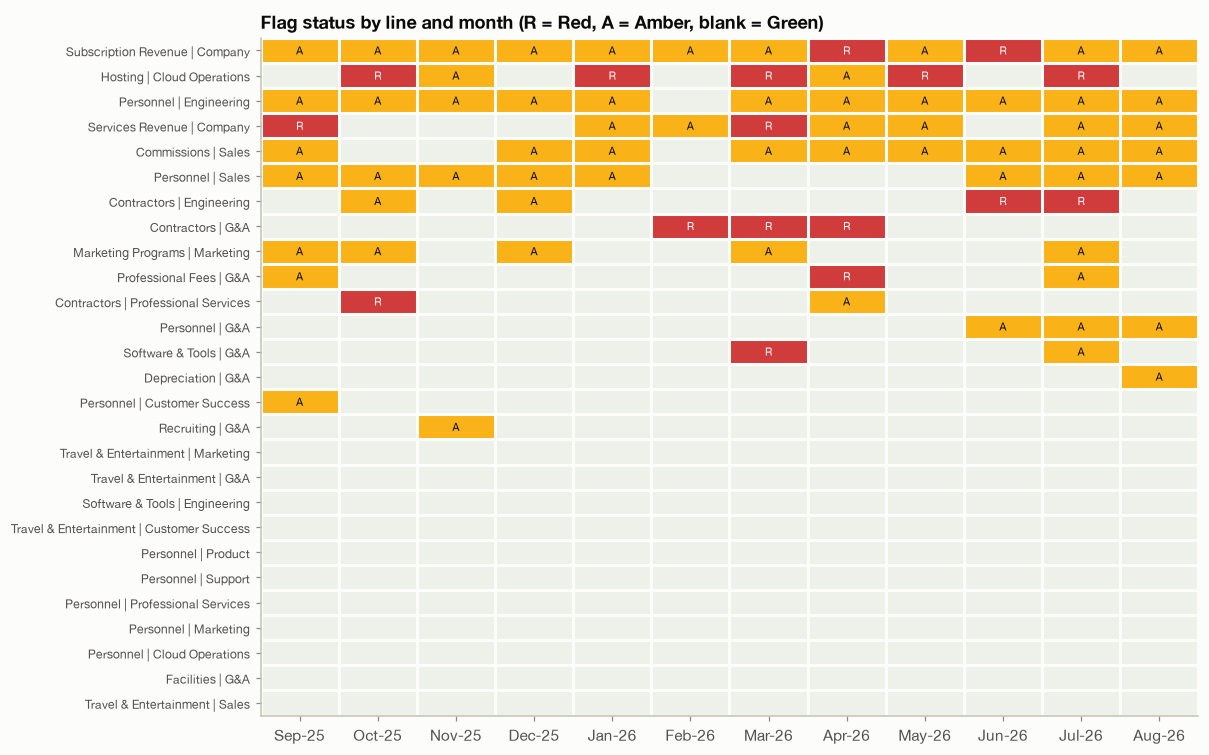

In [4]:
sev_code = {"Green": 0, "Amber": 1, "Red": 2}
grid = flags.pivot(index="unique_id", columns="period", values="severity")
grid = grid.loc[flags.groupby("unique_id")["severity"].apply(lambda s: s.map(sev_code).sum()).sort_values(ascending=False).index]
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#eef0ea", viz.STATUS["Amber"], viz.STATUS["Red"]])
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(grid.apply(lambda c: c.map(sev_code)).to_numpy(), cmap=cmap, vmin=0, vmax=2, aspect="auto")
labels = {"Red": "R", "Amber": "A", "Green": ""}
for (i, j), v in np.ndenumerate(grid.to_numpy()):
    ax.text(j, i, labels[v], ha="center", va="center", fontsize=7, color=viz.INK if v != "Red" else "white")
ax.set_xticks(range(grid.shape[1]), [pd.Period(p).strftime("%b-%y") for p in grid.columns])
ax.set_yticks(range(grid.shape[0]), grid.index, fontsize=8)
ax.grid(False)
ax.set_xticks(np.arange(-0.5, grid.shape[1]), minor=True); ax.set_yticks(np.arange(-0.5, grid.shape[0]), minor=True)
ax.grid(which="minor", color=viz.SURFACE, linewidth=2); ax.tick_params(which="minor", length=0)
ax.set_title("Flag status by line and month (R = Red, A = Amber, blank = Green)")
plt.show()

## 3. Drill-down: from a red flag to the journal entries

Every flag carries its top drivers: the spend items, customers or posting types that moved most versus a typical recent month (median of the prior 3 months). Payroll flags also get a **headcount-vs-rate** split.

In [5]:
red = flags[flags["severity"] == "Red"].sort_values("period")
example = red[red["fs_line"] == "Subscription Revenue"].iloc[-1] if (red["fs_line"] == "Subscription Revenue").any() else red.iloc[-1]
print(example["commentary"], "\n")
drivers = pd.DataFrame(json.loads(example["drivers"]))
drivers.style.format({"current_usd": usd, "typical_usd": usd, "change_usd": usd}).hide(axis="index")

Subscription Revenue was $410k (7%) under budget in Jun-26 (unfavourable). The actual of $5.08M fell outside the expected range of $5.58M to $5.96M from last month's forecast - likely a one-off or error to investigate. Biggest change vs a typical recent month: Credit memo - billing dispute - Northridge Logistics Inc. -$607k (1 document). 



driver,current_usd,typical_usd,change_usd,documents
Credit memo - billing dispute - Northridge Logistics Inc.,-$607k,$0,-$607k,1
Recurring subscription billing,$5.7M,$5.5M,$226k,3


In [6]:
detail = read("gl_detail_recent")
d = detail[(detail["fs_line"] == example["fs_line"]) & (detail["department"] == example["department"]) & (detail["period"] == example["period"])]
d.reindex(d["amount_usd"].abs().sort_values(ascending=False).index).head(5)[["je_id", "posting_date", "entity", "account_name", "description", "source", "amount_usd"]]

,je_id,posting_date,entity,account_name,description,source,amount_usd
16024,JE20260600069,2026-06-22,US01,Subscription Revenue,Credit memo - billing dispute - Northridge Logistics Inc.,AR,-607209.41
15371,JE20260600030,2026-06-30,US01,Subscription Revenue,Subscription revenue - Stonebridge Pharma,REVREC,60517.05
15489,JE20260600030,2026-06-30,US01,Subscription Revenue,Subscription revenue - Summitlight Pharma,REVREC,48695.34
15328,JE20260600030,2026-06-30,US01,Subscription Revenue,Subscription revenue - Prairiestack Insurance,REVREC,46542.52
15195,JE20260600030,2026-06-30,US01,Subscription Revenue,Subscription revenue - Ironshore Energy,REVREC,42296.52


In [7]:
pers = flags[(flags["fs_line"] == "Personnel") & (flags["personnel_split"] != "")].sort_values("period").iloc[-1]
print(pers["commentary"])

Personnel (Sales) was $66k (8%) under budget in Aug-26 (favourable). It was in line with last month's forecast, so the gap reflects the original plan rather than a surprise. This is the fifth consecutive month under budget. Headcount was 62 vs a plan of 67 (-5 heads = -$63k); cost per head accounted for -$3k. Biggest change vs a typical recent month: Payroll run +$10k (4 documents).


## 4. Does it work? Scoring the flags against the answer key

The data generator injected realistic anomalies: duplicate invoices, missed accruals, runaway cloud spend, miscoded cost centers, credit memos, unapproved spend. It recorded them in a hidden answer key that the pipeline never reads. I can therefore measure the flags the way you would score a fraud or anomaly detector:
- **Recall:** of the injected problems, how many got a Red flag?
- **Precision:** of the Red flags, how many were real problems?

In [8]:
ev = read("flag_evaluation")
summary = meta["variance"]["evaluation"]
print(f"Window {summary['window']}: {summary['anomalies_in_window']} injected anomalies, {summary['red_flags']} Red flags")
print(f"  Recall (Red):            {summary['recall_red']:.0%}")
print(f"  Precision (Red):         {summary['precision_red']:.0%}")
print(f"  Recall (Red or Amber):   {summary['recall_red_or_amber']:.0%}")
ev[["period", "type", "series", "approx_usd", "best_flag"]].style.format({"approx_usd": lambda v: "" if pd.isna(v) else usd(v)}).hide(axis="index")

Window 2025-09..2026-08: 13 injected anomalies, 17 Red flags
  Recall (Red):            92%
  Precision (Red):         82%
  Recall (Red or Amber):   100%


period,type,series,approx_usd,best_flag
2025-09,legal_settlement,Professional Fees | G&A,$247k,Amber
2025-10,cloud_cost_spike,Hosting | Cloud Operations,$253k,Red
2025-10,miscoded_cost_center,"Contractors | Engineering, Contractors | Professional Services",$92k,Red
2026-02,unbudgeted_contractors,Contractors | G&A,$148k,Red
2026-02,unbudgeted_contractors,Contractors | G&A,$115k,Red
2026-03,software_auto_renewal,Software & Tools | G&A,$187k,Red
2026-03,cloud_cost_spike,Hosting | Cloud Operations,$203k,Red
2026-04,legal_settlement,Professional Fees | G&A,$341k,Red
2026-04,revenue_credit_memo,Subscription Revenue | Company,$461k,Red
2026-05,cloud_cost_spike,Hosting | Cloud Operations,$252k,Red


In [9]:
impacted = set()
key = json.loads((ROOT / "data" / "raw" / "_answer_key.json").read_text())
for a in key["anomalies"]:
    for i in a["impacts"]:
        impacted.add((f"{i['fs_line']} | {i['department']}", i["period"]))
fp = flags[(flags["severity"] == "Red") & ~flags.apply(lambda r: (r["unique_id"], r["period"]) in impacted, axis=1)]
print("Red flags that were NOT injected anomalies (false positives):")
fp[["period", "unique_id", "var_budget_usd", "var_budget_pct", "commentary"]].style.format({"var_budget_usd": usd, "var_budget_pct": "{:+.0%}"}).hide(axis="index")

Red flags that were NOT injected anomalies (false positives):


period,unique_id,var_budget_usd,var_budget_pct,commentary
2026-01,Hosting | Cloud Operations,$135k,+20%,Hosting (Cloud Operations) was $135k (20%) over budget in Jan-26 (unfavourable). The actual of $797k fell outside the expected range of $578k to $794k from last month's forecast - likely a one-off or error to investigate. Biggest change vs a typical recent month: Cloud compute & storage +$14k (8 documents).
2025-09,Services Revenue | Company,$209k,+53%,Services Revenue was $209k (53%) over budget in Sep-25 (favourable). The actual of $601k fell outside the expected range of $355k to $558k from last month's forecast - likely a one-off or error to investigate. Biggest change vs a typical recent month: Implementation milestone - Bluemark Robotics +$84k (1 document).
2026-03,Services Revenue | Company,$343k,+68%,Services Revenue was $343k (68%) over budget in Mar-26 (favourable). The actual of $847k fell outside the expected range of $380k to $647k from last month's forecast - likely a one-off or error to investigate. Biggest change vs a typical recent month: Implementation milestone - Redforge Capital +$147k (1 document).


**Read-out:**
- The flags catch nearly all injected problems at Red and all of them at Red or Amber. About four in five Red flags are real issues, a manageable review list of about 1-2 lines a month instead of 27.
- The misses and false positives are instructive. A one-off on an already noisy line, such as legal fees, can land inside the wide expected range and only reach Amber. A genuine but unusual swing in a volatile line can trip Red without being an error, which is still worth a look.
- Trade-off lever: lower the materiality thresholds to catch more (higher recall) at the cost of more noise (lower precision). The thresholds live in a YAML file that FP&A can own.

## 5. Year-to-date view

In [10]:
ytd = read("variance_ytd").sort_values("var_usd")
ytd["status"] = np.where(ytd["material"], np.where(ytd["favourable"], "Material - favourable", "Material - unfavourable"), "")
(ytd[["fs_line", "department", "ytd_actual_usd", "ytd_budget_usd", "var_usd", "var_pct", "status"]]
 .style.format({"ytd_actual_usd": usd, "ytd_budget_usd": usd, "var_usd": usd, "var_pct": "{:+.1%}"}).hide(axis="index"))

fs_line,department,ytd_actual_usd,ytd_budget_usd,var_usd,var_pct,status
Personnel,Engineering,$11.6M,$12.5M,-$823k,-6.6%,Material - favourable
Commissions,Sales,$1.3M,$1.8M,-$510k,-27.7%,Material - favourable
Personnel,Sales,$6.0M,$6.4M,-$383k,-6.0%,Material - favourable
Personnel,G&A,$3.8M,$4.2M,-$323k,-7.8%,Material - favourable
Personnel,Marketing,$2.7M,$2.9M,-$236k,-8.1%,Material - favourable
Personnel,Professional Services,$1.7M,$1.9M,-$209k,-10.8%,Material - favourable
Services Revenue,Company,$3.8M,$4.0M,-$199k,-4.9%,
Personnel,Product,$1.8M,$1.9M,-$160k,-8.3%,Material - favourable
Facilities,G&A,$1.5M,$1.7M,-$155k,-9.2%,
Marketing Programs,Marketing,$2.3M,$2.3M,-$68k,-2.9%,


### Key takeaways
1. Combining **materiality** (the FP&A rule) with **statistical surprise** (the forecast's expected range) cuts 27 lines down to a short, high-precision "investigate" list.
2. Every flag arrives with a **draft commentary and drill-down** to vendors and journal entries, so the analyst edits instead of writing from scratch.
3. The approach is **measurable**: scored against a hidden answer key, it catches the large majority of injected accounting problems.